<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20Autoencoder/06_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN regime 1 (Autoencoder) · Compare Results
Loads the 5 methods' `results/*.json` from Drive (missing ones skipped). BCE + pixel-accuracy, cost/memory, three-factor cos-sweep head-to-head, and a sample-reconstruction grid.

## 1. Setup + Load Results

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device='cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section7_r1_autoencoder'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive'); STORE=os.path.join('/content/drive/MyDrive',DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:',e); STORE=os.path.join('/content',DRIVE_SUBDIR)
else:
    STORE=os.path.join('.',DRIVE_SUBDIR)
RESULTS_DIR=os.path.join(STORE,'results'); CKPT_DIR=os.path.join(STORE,'checkpoints')
METHODS=['backprop','two_factor','three_factor_clean','three_factor_normal','three_factor_noisy', 'backprop_100M']
LABELS={'backprop':'Backprop','two_factor':'Two-factor Hebbian','three_factor_clean':'Three-factor clean (cos~0.5)','three_factor_normal':'Three-factor normal (cos~0.09)','three_factor_noisy':'Three-factor noisy (cos~0.01)', 'backprop_100M':'Backprop 100M (ceiling)'}
COLORS={'backprop':'#1F3864','two_factor':'#B8860B','three_factor_clean':'#C62828','three_factor_normal':'#E67E22','three_factor_noisy':'#7B1FA2', 'backprop_100M':'#2E7D32'}
R={}
for m in METHODS:
    p=os.path.join(RESULTS_DIR,f'{m}.json')
    if os.path.exists(p):
        R[m]=json.load(open(p)); s=R[m]['summary']; md=R[m]['meta']
        print(f'loaded {m:24} {md["total_steps"]:>9,} steps  {md["wall_clock_sec"]/3600:5.2f}h  best BCE {s["best_bce"]:.4f}  best pixel-acc {s["best_acc"]:.4f}')
    else:
        print(f'MISSING {p} (run the {m} notebook first)')

Mounted at /content/drive
loaded backprop                 2,048,233 steps   1.50h  best BCE 0.0054  best pixel-acc 0.9988
loaded two_factor               2,971,590 steps   1.50h  best BCE 0.6983  best pixel-acc 0.8765
loaded three_factor_clean              21 steps   1.58h  best BCE 0.3450  best pixel-acc 0.8765
loaded three_factor_normal            663 steps   1.50h  best BCE 0.0749  best pixel-acc 0.9698
loaded three_factor_noisy          50,078 steps   1.50h  best BCE 0.0405  best pixel-acc 0.9841
loaded backprop_100M              345,572 steps   1.50h  best BCE 0.0391  best pixel-acc 0.9848


## 2. Compare curves (BCE + pixel-acc)

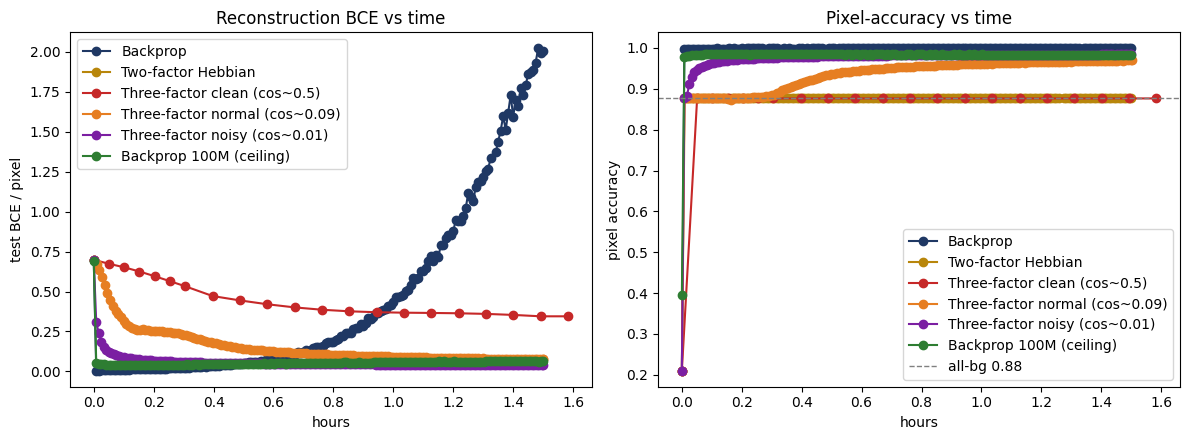

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_bce'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_acc'], 'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('hours'); ax[0].set_ylabel('test BCE / pixel'); ax[0].set_title('Reconstruction BCE vs time'); ax[0].legend()
if R:
    bg = list(R.values())[0]['summary'].get('bg_baseline');
    if bg: ax[1].axhline(bg, color='gray', ls='--', lw=1, label=f'all-bg {bg:.2f}')
ax[1].set_xlabel('hours'); ax[1].set_ylabel('pixel accuracy'); ax[1].set_title('Pixel-accuracy vs time'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Cost & Memory

In [3]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m.startswith('three_factor'): return st * 2 * R[m]['meta']['config'].get('M', 0)
    if m.startswith('backprop'): return st * 3
    return st * 2
print(f'{"method":30}{"steps":>10}{"fwd-equiv":>14}{"wall h":>8}{"peak MB":>9}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{fwd_equiv(m):>14,}{md["wall_clock_sec"]/3600:>8.2f}{md.get("peak_mem_mb", float("nan")):>9.1f}')

method                             steps     fwd-equiv  wall h  peak MB
-----------------------------------------------------------------------
Backprop                       2,048,233     6,144,699    1.50    635.4
Two-factor Hebbian             2,971,590     5,943,180    1.50    607.9
Three-factor clean (cos~0.5)          21    14,151,018    1.58  14566.1
Three-factor normal (cos~0.09)       663    10,944,804    1.50  17782.3
Three-factor noisy (cos~0.01)     50,078    10,115,756    1.50  11104.8
Backprop 100M (ceiling)          345,572     1,036,716    1.50   4879.3


## 4. Head-to-head — three-factor cos sweep

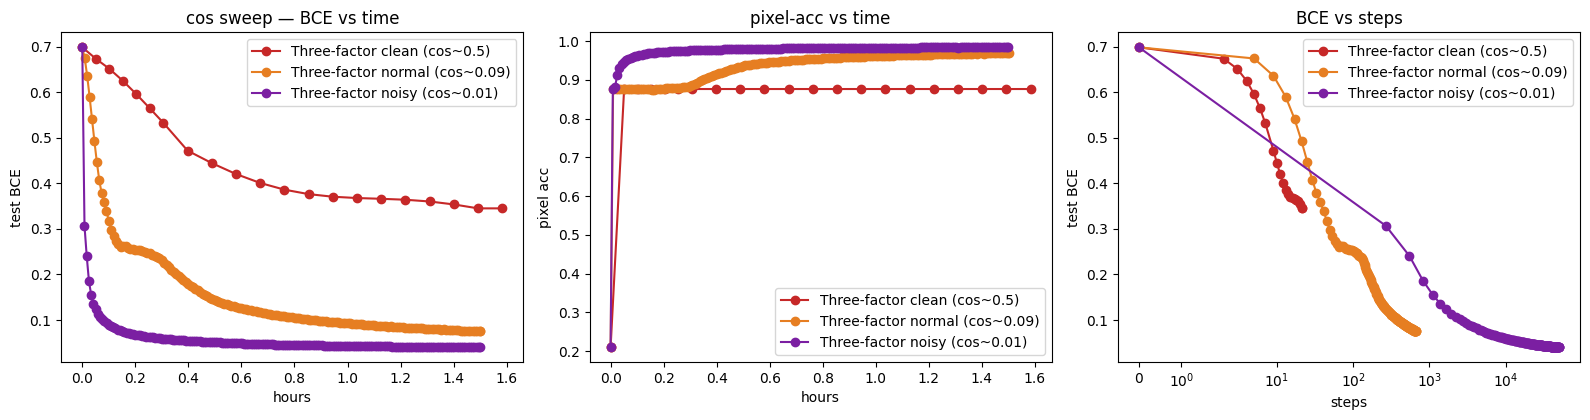

variant                                M    cos~     steps   best_bce  best_acc
-------------------------------------------------------------------------------
Three-factor clean (cos~0.5)     336,929   0.500        21     0.3450    0.8765
Three-factor normal (cos~0.09)     8,254   0.090       663     0.0749    0.9698
Three-factor noisy (cos~0.01)        101   0.010    50,078     0.0405    0.9841

Lowest best BCE in the budget: Three-factor noisy (cos~0.01).


In [4]:
tf = [m for m in ['three_factor_clean','three_factor_normal','three_factor_noisy'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_bce'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_bce'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('test BCE'); ax[0].set_title('cos sweep — BCE vs time'); ax[0].legend()
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('pixel acc'); ax[1].set_title('pixel-acc vs time'); ax[1].legend()
    ax[2].set_xscale('symlog'); ax[2].set_xlabel('steps'); ax[2].set_ylabel('test BCE'); ax[2].set_title('BCE vs steps'); ax[2].legend()
    plt.tight_layout(); plt.show()
    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_bce":>11}{"best_acc":>10}')
    print('-'*79)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_bce"]:>11.4f}{s["best_acc"]:>10.4f}')
    best = min(tf, key=lambda m: R[m]['summary']['best_bce'])
    print(f'\nLowest best BCE in the budget: {LABELS[best]}.')
else:
    print('Head-to-head needs >=2 three-factor variants (03/04/05).')

## 5. Sample reconstructions (best model)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 978kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


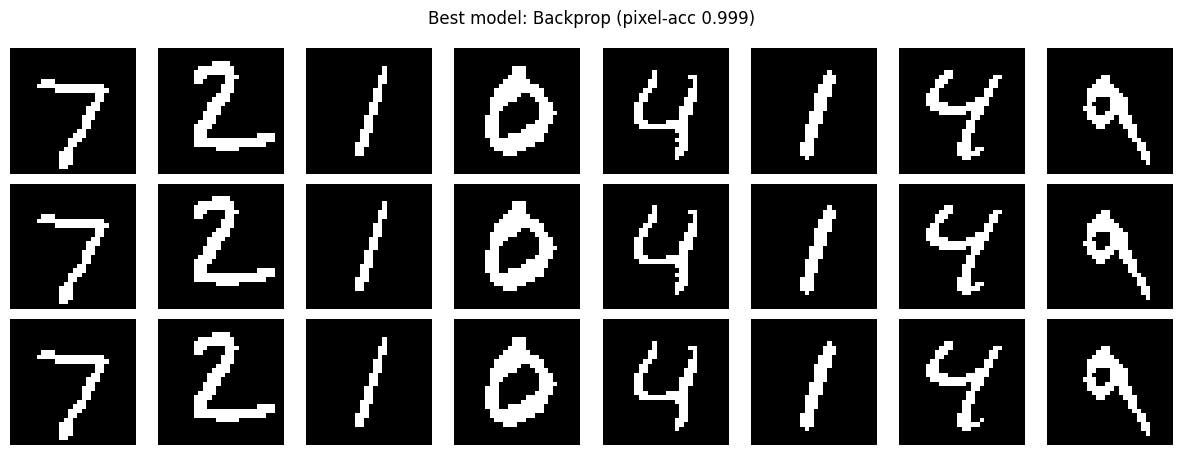

In [5]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 28x28 logits.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=48, latent=98):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(1, conv_c, 3, stride=2, padding=1), nn.ReLU(),   # 28 -> 14
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),  # 14 -> 7
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 7 * 7, latent)
        self.fc2 = nn.Linear(latent, c2 * 7 * 7)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),               # 7 -> 14
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),               # 14 -> 28
            nn.Conv2d(conv_c, 1, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 7, 7)
        return self.dec(h2)                                            # (B,1,28,28) logits

# sample reconstructions for the best model: input | target | reconstruction
import torch
if R:
    best = max(R, key=lambda m: R[m]['summary']['best_acc'])
    cfg = R[best]['meta']['config']
    net = ConvAE(cfg['CONV_C'], cfg['LATENT']).to(device)
    ck = torch.load(os.path.join(CKPT_DIR, f'{best}.pt'), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    import torchvision
    _te = torchvision.datasets.MNIST('./data', train=False, download=True)
    x = (_te.data[:8].float()/255.0 > 0.5).float().unsqueeze(1).to(device)
    torch.manual_seed(cfg['SEED']); xin = x + cfg['CORRUPT_SIGMA']*torch.randn_like(x) if cfg['CORRUPT_SIGMA']>0 else x
    with torch.no_grad(): rec = (torch.sigmoid(net(xin)) > 0.5).float()
    fig, ax = plt.subplots(3, 8, figsize=(12, 4.6))
    for j in range(8):
        ax[0,j].imshow(xin[j,0].cpu(), cmap='gray'); ax[1,j].imshow(x[j,0].cpu(), cmap='gray'); ax[2,j].imshow(rec[j,0].cpu(), cmap='gray')
        for r in range(3): ax[r,j].axis('off')
    ax[0,0].set_ylabel('input'); ax[1,0].set_ylabel('target'); ax[2,0].set_ylabel('reconstruction')
    plt.suptitle(f'Best model: {LABELS[best]} (pixel-acc {R[best]["summary"]["best_acc"]:.3f})'); plt.tight_layout(); plt.show()
else:
    print('no results loaded')

## 6. Summary table

In [6]:
print(f'{"Experiment":30}{"Steps":>10}{"Init BCE":>10}{"Best BCE":>10}{"Final acc":>11}{"Best acc":>10}')
print('-'*81)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{s["initial_bce"]:>10.4f}{s["best_bce"]:>10.4f}{s["final_acc"]:>11.4f}{s["best_acc"]:>10.4f}')
print(f'\n(all-background pixel-acc baseline = {list(R.values())[0]["summary"]["bg_baseline"]:.3f} — methods must beat this)' if R else '')

Experiment                         Steps  Init BCE  Best BCE  Final acc  Best acc
---------------------------------------------------------------------------------
Backprop                       2,048,233    0.6983    0.0054     0.9988    0.9988
Two-factor Hebbian             2,971,590    0.6983    0.6983     0.8765    0.8765
Three-factor clean (cos~0.5)          21    0.6983    0.3450     0.8765    0.8765
Three-factor normal (cos~0.09)       663    0.6983    0.0749     0.9698    0.9698
Three-factor noisy (cos~0.01)     50,078    0.6983    0.0405     0.9841    0.9841
Backprop 100M (ceiling)          345,572    0.6940    0.0391     0.9836    0.9848

(all-background pixel-acc baseline = 0.876 — methods must beat this)
